# EDA — World Football ELO Ratings
**Sources**: `elo_ratings/eloratings.csv` (1872–present, all internationals) + `elo_ratings/elo_ratings_wc2026.csv` (historical snapshots for 48 WC 2026 teams)

**Purpose**: Understand ELO rating distributions, temporal stability, coverage of WC 2026 teams, and suitability as the primary team-strength feature.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
DATA = Path('../data/raw/elo_ratings')

## 1. Load & Basic Profile

In [2]:
elo = pd.read_csv(DATA / 'eloratings.csv')
elo['date'] = pd.to_datetime(elo['date'], format='mixed')
elo_wc = pd.read_csv(DATA / 'elo_ratings_wc2026.csv')
elo_wc['snapshot_date'] = pd.to_datetime(elo_wc['snapshot_date'], format='mixed')

print('ELO ratings shape:', elo.shape)
print('ELO ratings columns:', elo.columns.tolist())
print('ELO ratings date range:', elo['date'].min(), '->', elo['date'].max())
print('Unique teams:', elo['team'].nunique())
print()
print('WC 2026 ELO shape:', elo_wc.shape)
print('WC 2026 ELO columns:', elo_wc.columns.tolist())
elo.head(3)

ELO ratings shape: (6678, 4)
ELO ratings columns: ['date', 'team', 'rating', 'change']
ELO ratings date range: 1872-11-30 00:00:00 -> 2025-12-13 00:00:00
Unique teams: 270

WC 2026 ELO shape: (4683, 23)
WC 2026 ELO columns: ['year', 'snapshot_date', 'country', 'rank', 'country_code', 'rating', 'rank_max', 'rating_max', 'rank_avg', 'rating_avg', 'rank_min', 'rating_min', 'matches_total', 'matches_home', 'matches_away', 'matches_neutral', 'wins', 'losses', 'draws', 'goals_for', 'goals_against', 'confederation', 'is_host']


,date,team,rating,change
0,1872-11-30,England,2003.0,3
1,1872-11-30,Scotland,1997.0,-3
2,1873-03-08,England,2014.0,11


In [3]:
print('Missing values:')
print(elo.isnull().sum())
print()
print('Rating range:', elo['rating'].min(), '-', elo['rating'].max())
print('Rating mean:', elo['rating'].mean())
print('Change range:', elo['change'].min(), '-', elo['change'].max())

Missing values:
date       0
team       0
rating    31
change     0
dtype: int64

Rating range: 0.0 - 2171.0
Rating mean: 1490.960734165789
Change range: -86 - 86


## 2. Current ELO Rankings (Latest Snapshot)

Latest ELO date: 2025-12-13 00:00:00

Top 20 teams by current ELO:
          team  rating       date
         Spain  2171.0 2025-12-13
  West Germany  2144.0 1974-09-04
     Argentina  2113.0 2025-12-13
        France  2062.0 2025-12-13
       England  2042.0 2025-12-13
      Colombia  1998.0 2025-12-13
        Brazil  1979.0 2025-12-13
      Portugal  1976.0 2025-12-13
   Netherlands  1959.0 2025-12-13
       Ecuador  1933.0 2025-12-13
       Croatia  1933.0 2025-12-13
        Norway  1922.0 2025-12-13
       Germany  1910.0 2025-12-13
  Soviet Union  1899.0 1991-05-29
   Switzerland  1897.0 2025-12-13
       Uruguay  1890.0 2025-12-13
        Turkey  1880.0 2025-12-13
         Japan  1878.0 2025-12-13
       Denmark  1864.0 2025-12-13
Czechoslovakia  1864.0 1992-04-22


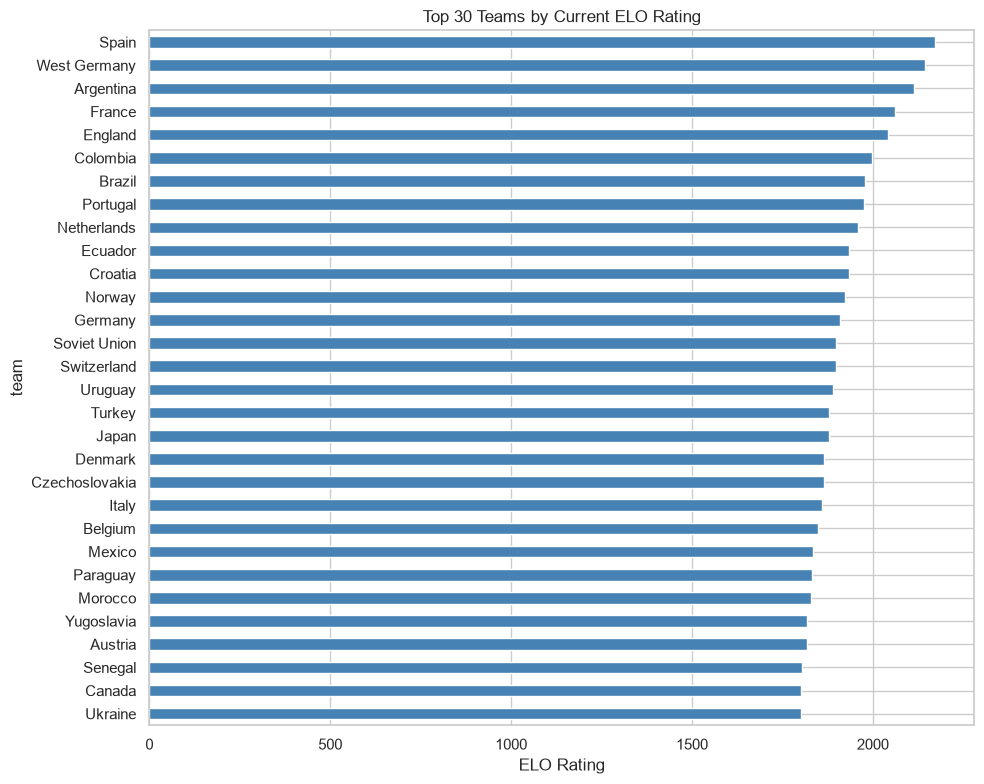

In [4]:
latest_elo = elo.sort_values('date').groupby('team').last().reset_index()
latest_elo = latest_elo.sort_values('rating', ascending=False)

print('Latest ELO date:', latest_elo['date'].max())
print('\nTop 20 teams by current ELO:')
print(latest_elo[['team', 'rating', 'date']].head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
latest_elo.head(30).sort_values('rating').plot(
    kind='barh', x='team', y='rating', ax=ax, legend=False, color='steelblue'
)
ax.set_title('Top 30 Teams by Current ELO Rating')
ax.set_xlabel('ELO Rating')
plt.tight_layout()
plt.show()

## 3. ELO Distribution Across All Teams

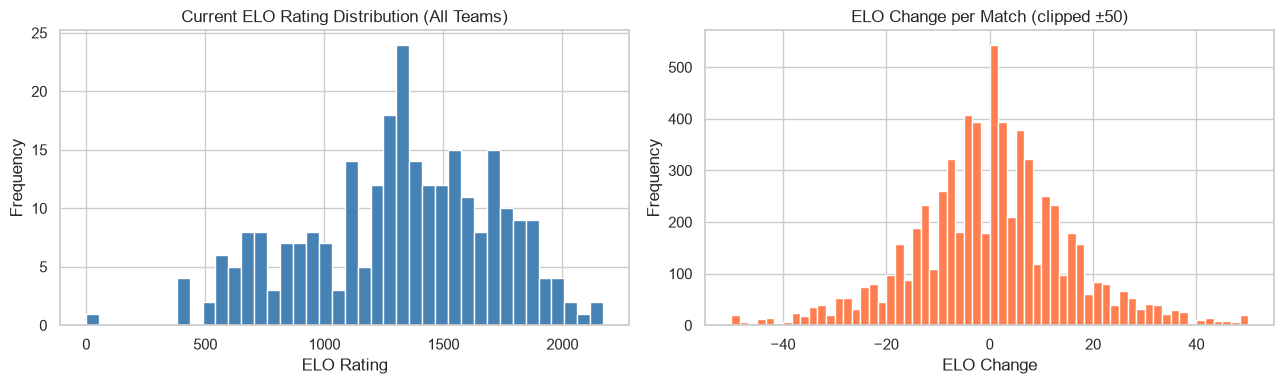

ELO distribution stats:
count     270.000000
mean     1315.496296
std       401.786760
min         0.000000
25%      1062.000000
50%      1340.000000
75%      1611.000000
max      2171.000000
Name: rating, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

latest_elo['rating'].plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Current ELO Rating Distribution (All Teams)')
axes[0].set_xlabel('ELO Rating')

elo['change'].clip(-50, 50).plot(kind='hist', bins=60, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('ELO Change per Match (clipped ±50)')
axes[1].set_xlabel('ELO Change')

plt.tight_layout()
plt.show()

print('ELO distribution stats:')
print(latest_elo['rating'].describe())

## 4. Historical ELO Trajectories — Top 8 Teams

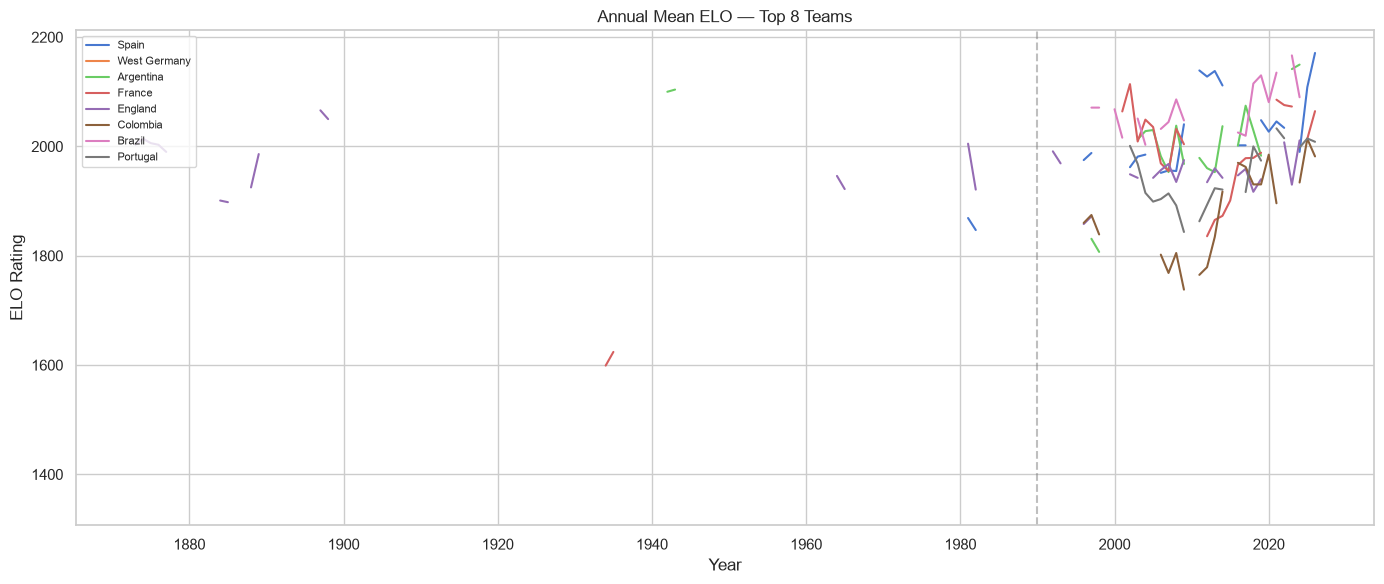

In [6]:
top8 = latest_elo.head(8)['team'].tolist()

fig, ax = plt.subplots(figsize=(14, 6))

for team in top8:
    team_elo = elo[elo['team'] == team].sort_values('date')
    # Smooth with rolling mean for readability
    team_elo_annual = team_elo.set_index('date')['rating'].resample('YE').mean()
    ax.plot(team_elo_annual.index, team_elo_annual.values, label=team, linewidth=1.5)

ax.set_title('Annual Mean ELO — Top 8 Teams')
ax.set_xlabel('Year')
ax.set_ylabel('ELO Rating')
ax.legend(loc='upper left', fontsize=8)
ax.axvline(pd.Timestamp('1990-01-01'), color='gray', linestyle='--', alpha=0.5, label='1990 (training cutoff candidate)')
plt.tight_layout()
plt.show()

## 5. WC 2026 Teams — ELO Coverage Check

In [7]:
print('WC 2026 ELO dataset — unique years:', sorted(elo_wc['year'].unique()))
print('Unique teams:', elo_wc['country'].nunique())

# Get pre-tournament snapshot (most recent year)
latest_wc_snap = elo_wc.sort_values('snapshot_date').groupby('country').last().reset_index()
latest_wc_snap = latest_wc_snap.sort_values('rating', ascending=False)

print('\nWC 2026 teams by pre-tournament ELO:')
print(latest_wc_snap[['country', 'rating', 'confederation', 'snapshot_date']].head(48).to_string(index=False))

WC 2026 ELO dataset — unique years: [np.int64(1901), np.int64(1902), np.int64(1903), np.int64(1904), np.int64(1905), np.int64(1906), np.int64(1907), np.int64(1908), np.int64(1909), np.int64(1910), np.int64(1911), np.int64(1912), np.int64(1913), np.int64(1914), np.int64(1915), np.int64(1916), np.int64(1917), np.int64(1918), np.int64(1919), np.int64(1920), np.int64(1921), np.int64(1922), np.int64(1923), np.int64(1924), np.int64(1925), np.int64(1926), np.int64(1927), np.int64(1928), np.int64(1929), np.int64(1930), np.int64(1931), np.int64(1932), np.int64(1933), np.int64(1934), np.int64(1935), np.int64(1936), np.int64(1937), np.int64(1938), np.int64(1939), np.int64(1940), np.int64(1941), np.int64(1942), np.int64(1943), np.int64(1944), np.int64(1945), np.int64(1946), np.int64(1947), np.int64(1948), np.int64(1949), np.int64(1950), np.int64(1951), np.int64(1952), np.int64(1953), np.int64(1954), np.int64(1955), np.int64(1956), np.int64(1957), np.int64(1958), np.int64(1959), np.int64(1960), np.

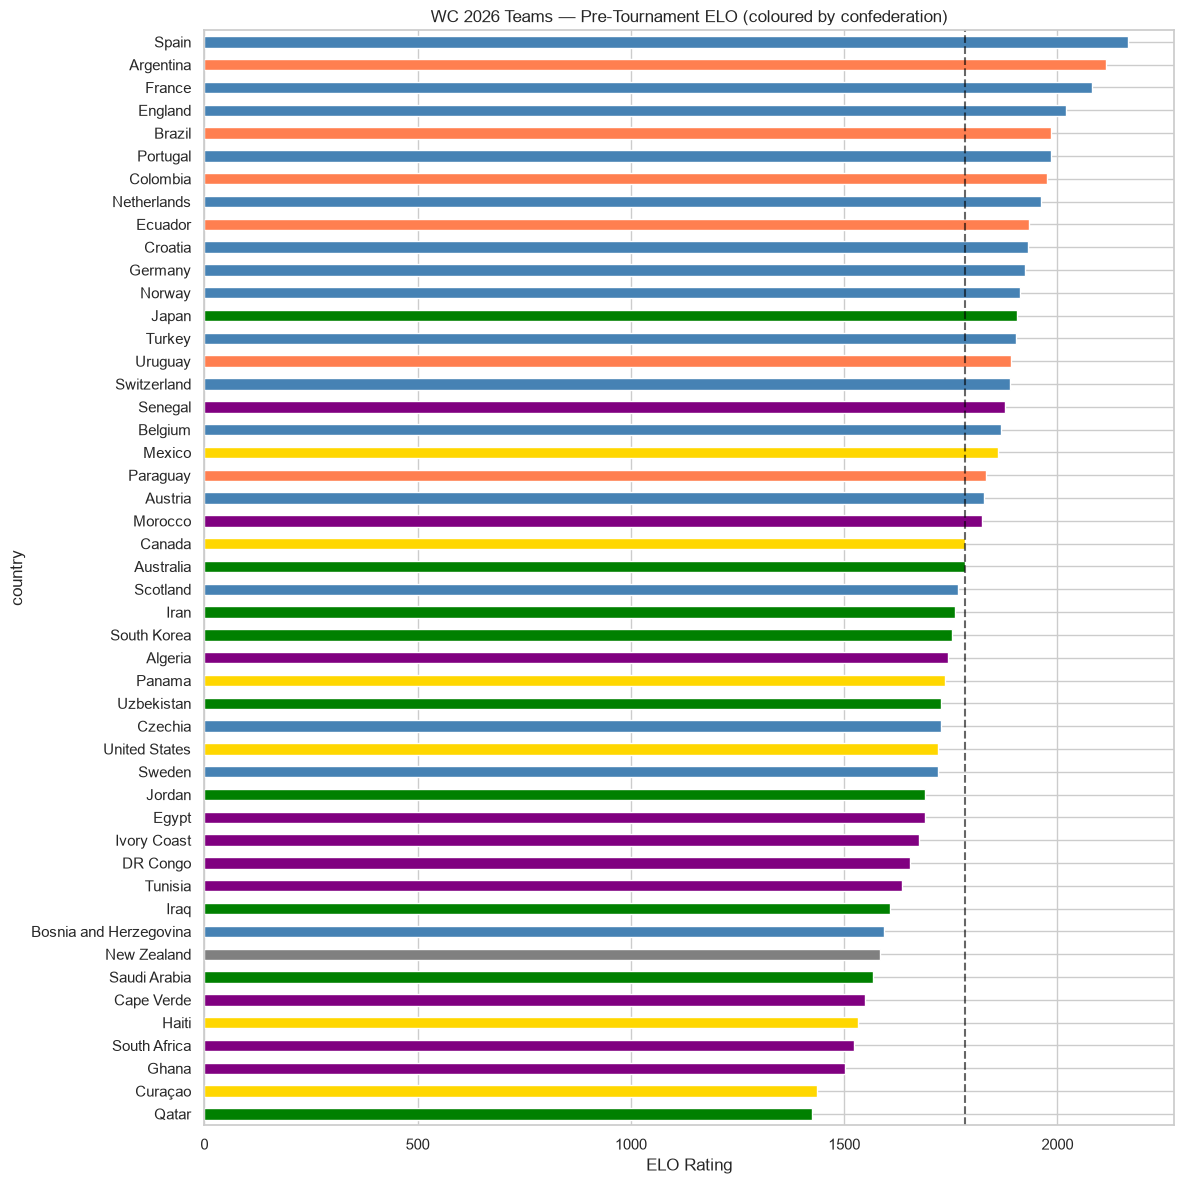

In [8]:
fig, ax = plt.subplots(figsize=(12, 12))
latest_wc_snap.sort_values('rating').plot(
    kind='barh', x='country', y='rating', ax=ax, legend=False,
    color=latest_wc_snap.sort_values('rating')['confederation'].map({
        'UEFA': 'steelblue', 'CONMEBOL': 'coral', 'CONCACAF': 'gold',
        'AFC': 'green', 'CAF': 'purple', 'OFC': 'gray'
    }).fillna('lightgray')
)
ax.set_title('WC 2026 Teams — Pre-Tournament ELO (coloured by confederation)')
ax.set_xlabel('ELO Rating')
ax.axvline(latest_wc_snap['rating'].mean(), color='black', linestyle='--', alpha=0.6, label='Mean')
plt.tight_layout()
plt.show()

## 6. ELO vs Win Rate Validation

In [9]:
# Check that higher ELO at match time predicts wins (basic sanity check)
# Join elo to results by date + team
results = pd.read_csv('../data/raw/mart_jurisoo/results.csv')
results['date'] = pd.to_datetime(results['date'], format='%Y-%m-%d')
results_clean = results.dropna(subset=['home_score', 'away_score'])

# Get ELO just before each match
elo_sorted = elo.sort_values('date')

def get_elo_at_date(team, match_date):
    mask = (elo_sorted['team'] == team) & (elo_sorted['date'] <= match_date)
    subset = elo_sorted[mask]
    return subset['rating'].iloc[-1] if len(subset) > 0 else np.nan

# Sample 2000 matches for speed
sample = results_clean[results_clean['date'] >= '2010-01-01'].sample(2000, random_state=42)

print('Computing ELO ratings for sample matches...')
sample = sample.copy()
sample['home_elo'] = [get_elo_at_date(r.home_team, r.date) for r in sample.itertuples()]
sample['away_elo'] = [get_elo_at_date(r.away_team, r.date) for r in sample.itertuples()]
sample = sample.dropna(subset=['home_elo', 'away_elo'])
sample['elo_diff'] = sample['home_elo'] - sample['away_elo']
sample['result'] = (sample['home_score'] > sample['away_score']).astype(int)  # 1=home win

print(f'Sample size after ELO join: {len(sample)}')

Computing ELO ratings for sample matches...


Sample size after ELO join: 1242


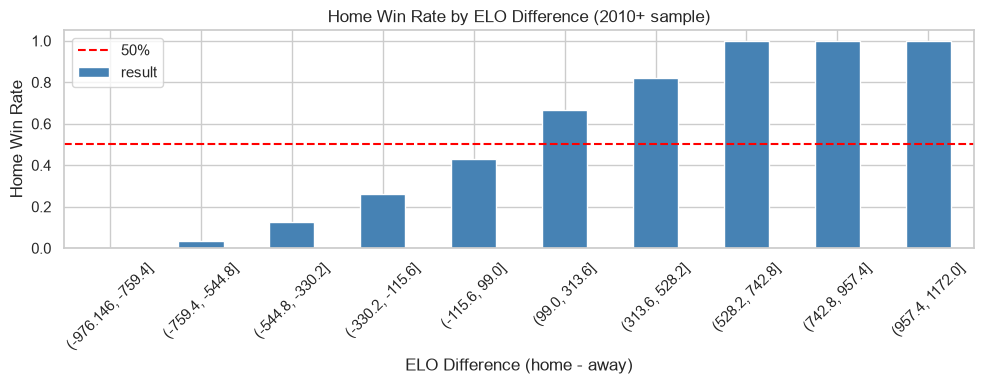

Point-biserial correlation (ELO diff vs home win): r=0.474, p=0.0000


In [10]:
# Bin by ELO diff and plot win rate
sample['elo_bin'] = pd.cut(sample['elo_diff'], bins=10)
win_by_elo = sample.groupby('elo_bin')['result'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
win_by_elo.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(0.5, color='red', linestyle='--', label='50%')
ax.set_title('Home Win Rate by ELO Difference (2010+ sample)')
ax.set_xlabel('ELO Difference (home - away)')
ax.set_ylabel('Home Win Rate')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

from scipy.stats import pointbiserialr
r, p = pointbiserialr(sample['elo_diff'], sample['result'])
print(f'Point-biserial correlation (ELO diff vs home win): r={r:.3f}, p={p:.4f}')

## 7. Red Flags Summary

In [11]:
red_flags = []

elo_missing = elo.isnull().sum().sum()
if elo_missing > 0:
    red_flags.append(f'Missing values in eloratings.csv: {elo_missing} cells')

elo_latest_date = elo['date'].max()
import datetime
today = datetime.date(2026, 6, 12)
days_stale = (today - elo_latest_date.date()).days
if days_stale > 30:
    red_flags.append(f'eloratings.csv is {days_stale} days stale — use elo_ratings_wc2026.csv for pre-tournament snapshot')

wc_teams_in_full_elo = set(latest_wc_snap['country']) & set(latest_elo['team'])
missing_from_full = set(latest_wc_snap['country']) - set(latest_elo['team'])
if missing_from_full:
    red_flags.append(f'WC 2026 teams missing from full eloratings.csv: {missing_from_full}')

if red_flags:
    print('RED FLAGS:')
    for f in red_flags:
        print(' -', f)
else:
    print('No red flags — ELO data looks clean and well-suited as primary feature.')

RED FLAGS:
 - Missing values in eloratings.csv: 31 cells
 - eloratings.csv is 181 days stale — use elo_ratings_wc2026.csv for pre-tournament snapshot
 - WC 2026 teams missing from full eloratings.csv: {'South Africa', 'Ivory Coast', 'Cape Verde', 'Bosnia and Herzegovina', 'DR Congo', 'United States', 'New Zealand', 'Saudi Arabia', 'South Korea'}
